# Desing of experiments - Binding capacity

### Data importing

In [1]:
from pandas import read_csv

experiments = read_csv('../data/efficiency.csv', index_col="No")
experiments

,pH,Excess,Efficiency
No,,,
1,7.00,5.0,128
2,8.50,5.0,48
3,7.00,10.0,228
4,8.50,10.0,109
5,7.00,7.5,183
6,8.50,7.5,69
7,7.75,5.0,88
8,7.75,10.0,176
9,7.75,7.5,139


### Creating a model

From the module: 'models.two_factors' we import LIT class. 

The model represented by this class has linear and interaction terms.

$y = f(x_{1}, x_{2}) = \beta_{0} + \beta_{1} x_{1}  + \beta_{2} x_{2} + \beta_{12} x_{1} x_{2} + e$

In [2]:
from models.two_factors import LIT

model = LIT(x_1 = "pH",
            x_2 = "Excess",
            y_i = "Efficiency",
            Data = experiments)

## Model validation

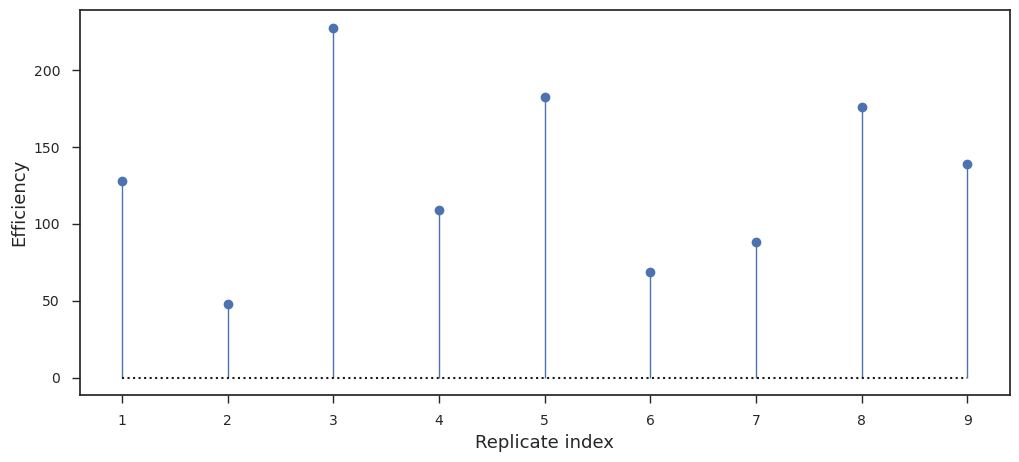

In [3]:
model.replicate_plot()

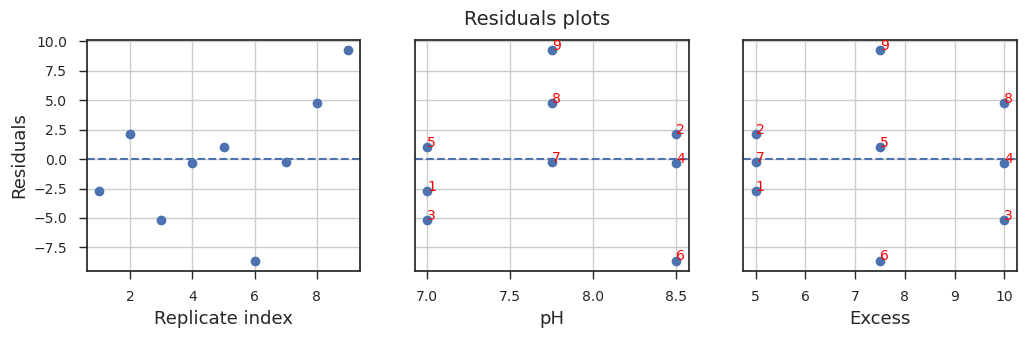

In [4]:
model.residuals_plot()

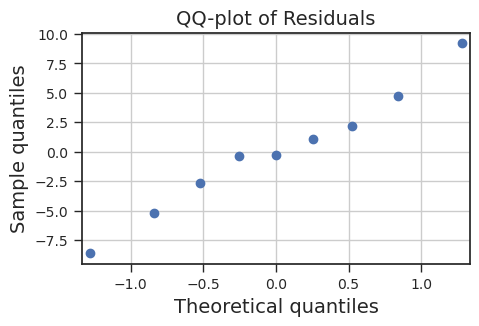

In [5]:
model.qq_plot()

In [6]:
model.shapiro

,Shapiro
p-value,0.994743


In [7]:
model.equation

beta_0 + beta_1*x_1 + beta_12*x_1*x_2 + beta_2*x_2

In [8]:
model.equation_subs

-5.20000000001355*x_1*x_2 - 30.5555555556241*x_1 + 56.9000000001222*x_2 + 242.083333333857

In [9]:
model.coefficients_stats

,beta_0,beta_1,beta_2,beta_12
Value,242.083333,-30.555556,56.9,-5.2
Standard error,107.28485,13.800193,13.802571,1.775443
t Statistic,2.256454,-2.21414,4.12242,-2.928846
p-value,0.073678,0.077699,0.009152,0.032676
Significance,ns,ns,**,*


In [10]:
model.anova

,df,SS,MS,F,p-value,Significance
Regression,3,27041.916667,9013.972222,203.348164,0.000012,****
Error,5,221.638889,44.327778,,,
Total,8,27263.555556,,,,


In [11]:
model.stats

,Model
R squared,0.991871
R squared adjusted,0.986993
RMSE,6.657911


In [12]:
model.DataFramePredicted

,pH,Excess,Efficiency,Efficiency^
No,,,,
1,7.00,5.0,128,130.69
2,8.50,5.0,48,45.86
3,7.00,10.0,228,233.19
4,8.50,10.0,109,109.36
5,7.00,7.5,183,181.94
6,8.50,7.5,69,77.61
7,7.75,5.0,88,88.28
8,7.75,10.0,176,171.28
9,7.75,7.5,139,129.78


## Plots

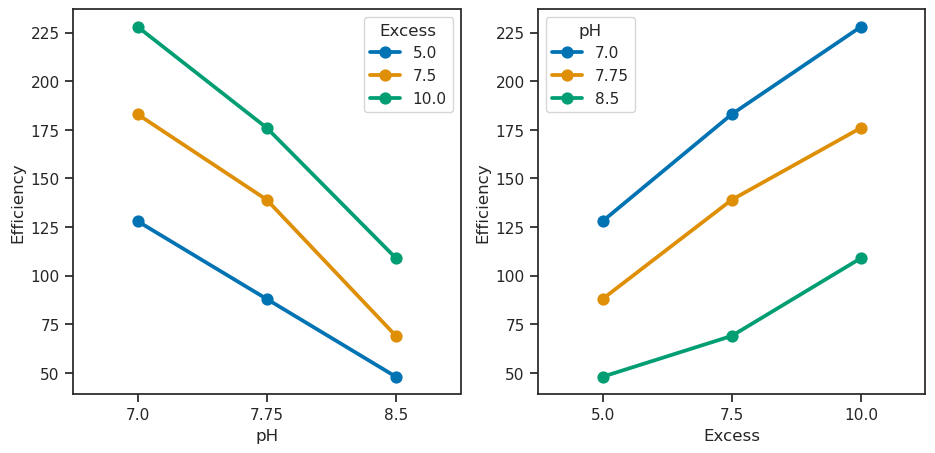

In [13]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
model.interaction_plot()

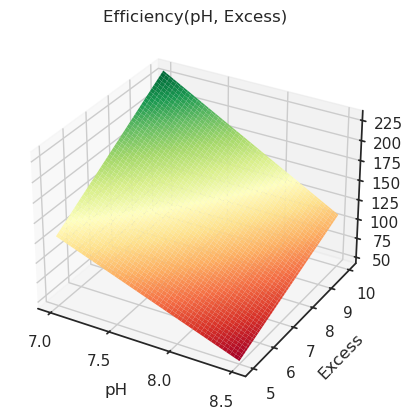

In [14]:
model.rsp3d(color="RdYlGn", stepx1=0.5, stepx2=1, stepx1add=0.5)

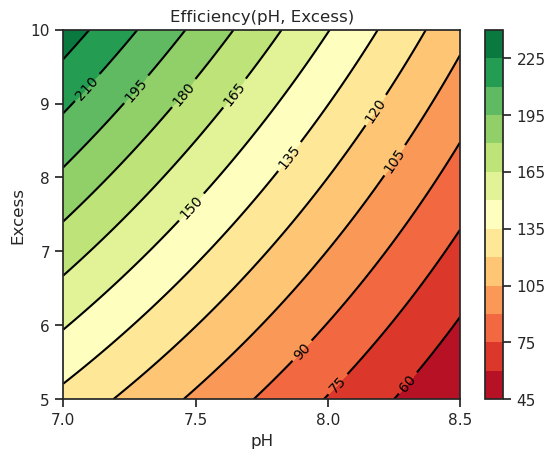

In [15]:
model.rsp(contours=15, cmap="RdYlGn", colors="black", stepx1=0.5, stepx2=1, font=10, stepx1add=0.5)

In [34]:
model.summary()

ANOVA
╒════════════╤══════╤═══════════╤═══════════════════╤════════════════════╤════════════════════════╤════════════════╕
│            │   df │        SS │ MS                │ F                  │ p-value                │ Significance   │
╞════════════╪══════╪═══════════╪═══════════════════╪════════════════════╪════════════════════════╪════════════════╡
│ Regression │    3 │ 27041.9   │ 9013.972222256627 │ 203.34816393109267 │ 1.2103863364587575e-05 │ ****           │
├────────────┼──────┼───────────┼───────────────────┼────────────────────┼────────────────────────┼────────────────┤
│ Error      │    5 │   221.639 │ 44.3277777777779  │                    │                        │                │
├────────────┼──────┼───────────┼───────────────────┼────────────────────┼────────────────────────┼────────────────┤
│ Total      │    8 │ 27263.6   │                   │                    │                        │                │
╘════════════╧══════╧═══════════╧═══════════════════╧═════